# 梯度下降法

求目标函数（损失函数）（代价函数）的最小值

$$J(\beta) = \frac{1}{n} \|X\beta - y\|_2^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i^T \beta - y_i)^2$$

可求得代价函数梯度：

$$\nabla J(\beta) = \frac{2}{n} X^T (X\beta - y)$$

参数更新公式：

$$\beta_{t+1} = \beta_t - \alpha \cdot \nabla J(\beta_t)$$

其中：

* $\alpha$ ：学习率（Learning Rate），用于控制步长
* $\nabla J(\beta_t)$：目标函数在 $\beta_t$ 处的梯度（各元偏导数组成的向量）

梯度推导公式：https://chat.deepseek.com/share/nmoh2f6bqzvbzio2xw

In [11]:
import numpy as np

# 1. 定义数据
X = np.array([[5], [8], [10], [12], [15], [3], [7], [9], [14], [6]])  # 自变量，每周学习时长
y = np.array([[55], [65], [70], [75], [85], [50], [60], [72], [80], [58]])

# 2. 数据处理
n = X.shape[0]
X = np.hstack( (np.ones((n, 1)), X) ) # 常数项
X, X.shape, X.T.shape

(array([[ 1.,  5.],
        [ 1.,  8.],
        [ 1., 10.],
        [ 1., 12.],
        [ 1., 15.],
        [ 1.,  3.],
        [ 1.,  7.],
        [ 1.,  9.],
        [ 1., 14.],
        [ 1.,  6.]]),
 (10, 2),
 (2, 10))

$$J(\beta) = \frac{1}{n} \sum_{i=1}^{n} (x_i^T \beta - y_i)^2$$

In [12]:
# 定义损失函数
def J(X, y, beta):
    return np.sum( (X @ beta - y ) ** 2 ) / n

$$\nabla J(\beta) = \frac{2}{n} X^T (X\beta - y)$$

In [13]:
# 定义梯度函数
def g(X, y, beta):
    return X.T @ (X @ beta - y) * 2 / n

$$\beta_{t+1} = \beta_t - \alpha \cdot \nabla J(\beta_t)$$

In [14]:
# 初始化参数和超参数
alpha = 0.01
iter = 10000
beta = np.array([[1], [1]])

# 定义列表，储存轨迹
beta0 = []
beta1 = []

In [15]:
# 开始迭代
while (np.abs(grad := g(X, y, beta)) > 1e-6).any() and (iter := iter - 1) >= 0:
    beta0.append(beta[0, 0])
    beta1.append(beta[1, 0])

    beta = beta - alpha * grad

    # 每 10 次迭代打印一次当前参数和损失值
    if iter % 10 == 0:
        print(f'beta: {beta.reshape(-1)}\tJ: {J(X, y, beta)}\t grad: {grad.reshape(-1)}')

print(10000 - iter)

beta: [2.55304472 5.08844061]	J: 437.4123991274335	 grad: [ 19.50584157 322.67074362]
beta: [3.77613762 6.08686801]	J: 226.50199857327053	 grad: [-2.89861692 85.73499796]
beta: [4.88888271 6.27390035]	J: 200.89042504765948	 grad: [-8.56645708 23.32404768]
beta: [5.94978139 6.249467  ]	J: 188.75080371892955	 grad: [-9.83397026  6.86872909]
beta: [6.97489487 6.17147532]	J: 178.1340871063524	 grad: [-9.94929424  2.5148383 ]
beta: [7.96909023 6.08144347]	J: 168.17833588929187	 grad: [-9.76752544  1.34803871]
beta: [8.93426862 5.99024434]	J: 158.79223363822547	 grad: [-9.51364211  1.02103464]
beta: [9.87153236 5.90068321]	J: 149.9396876551197	 grad: [-9.24670814  0.91573109]
beta: [10.78175607  5.81344267]	J: 141.59012507745786	 grad: [-8.98210477  0.86935796]
beta: [11.66573755  5.72864799]	J: 133.71495059950936	 grad: [-8.7237159   0.83903952]
beta: [12.52423807  5.64627929]	J: 126.28721025717259	 grad: [-8.47240279  0.81347043]
beta: [13.35799333  5.56627996]	J: 119.28148265270227	 grad:

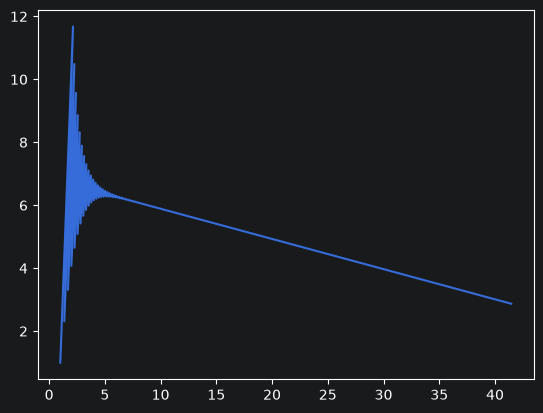

In [16]:
# 画图
import matplotlib.pyplot as plt
plt.plot(beta0, beta1)
plt.show()